In [14]:
# ============================================
# MACHINE LEARNING ASSIGNMENT - 2
# Credit Card Default Prediction
# ============================================

# Import required libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load the dataset
from google.colab import drive
drive.mount('/content/drive')

# Dataset location
DATASET_PATH = "/content/drive/My Drive/dataset/credit_card_default.csv"
df = pd.read_csv(DATASET_PATH)

# Display first 5 rows
df.head()

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


,Unnamed: 0,limit_bal,sex,education,marriage,age,payment_status_sep,payment_status_aug,payment_status_jul,payment_status_jun,...,bill_statement_jun,bill_statement_may,bill_statement_apr,previous_payment_sep,previous_payment_aug,previous_payment_jul,previous_payment_jun,previous_payment_may,previous_payment_apr,default_payment_next_month
0,0,20000,Female,University,Married,24.0,Payment delayed 2 months,Payment delayed 2 months,Payed duly,Payed duly,...,0,0,0,0,689,0,0,0,0,1
1,1,120000,Female,University,Single,26.0,Payed duly,Payment delayed 2 months,Unknown,Unknown,...,3272,3455,3261,0,1000,1000,1000,0,2000,1
2,2,90000,Female,University,Single,34.0,Unknown,Unknown,Unknown,Unknown,...,14331,14948,15549,1518,1500,1000,1000,1000,5000,0
3,3,50000,Female,University,Married,37.0,Unknown,Unknown,Unknown,Unknown,...,28314,28959,29547,2000,2019,1200,1100,1069,1000,0
4,4,50000,Male,University,Married,57.0,Payed duly,Unknown,Payed duly,Unknown,...,20940,19146,19131,2000,36681,10000,9000,689,679,0


In [15]:
# ============================================
# Data Preprocessing
# ============================================

import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder


# --------------------------------------------
# 1. Reload dataset
# --------------------------------------------

df = pd.read_csv(DATASET_PATH)

print("Original dataset shape:", df.shape)


# --------------------------------------------
# 2. Remove unnecessary index column
# --------------------------------------------

df = df.drop(columns=["Unnamed: 0"])

print("After removing index:", df.shape)


# --------------------------------------------
# 3. Define target
# --------------------------------------------

target_column = "default_payment_next_month"


# --------------------------------------------
# 4. Define feature groups
# --------------------------------------------

# Numerical features
numerical_features = [
    "limit_bal",
    "age",
    "bill_statement_sep",
    "bill_statement_aug",
    "bill_statement_jul",
    "bill_statement_jun",
    "bill_statement_may",
    "bill_statement_apr",
    "previous_payment_sep",
    "previous_payment_aug",
    "previous_payment_jul",
    "previous_payment_jun",
    "previous_payment_may",
    "previous_payment_apr"
]


# Demographic categorical features
categorical_features = [
    "sex",
    "education",
    "marriage"
]


# Payment-status features
payment_features = [
    "payment_status_sep",
    "payment_status_aug",
    "payment_status_jul",
    "payment_status_jun",
    "payment_status_may",
    "payment_status_apr"
]


# --------------------------------------------
# 5. Encode payment status
# --------------------------------------------

payment_mapping = {
    "Unknown": -1,
    "Payed duly": 0,
    "Payment delayed 1 month": 1,
    "Payment delayed 2 months": 2,
    "Payment delayed 3 months": 3,
    "Payment delayed 4 months": 4,
    "Payment delayed 5 months": 5,
    "Payment delayed 6 months": 6,
    "Payment delayed 7 months": 7,
    "Payment delayed 8 months": 8
}

for column in payment_features:
    df[column] = df[column].map(payment_mapping)


# --------------------------------------------
# 6. Separate features and target
# --------------------------------------------

X = df.drop(columns=[target_column])
y = df[target_column]


print("\nFeature matrix X shape:", X.shape)
print("Target vector y shape :", y.shape)


# --------------------------------------------
# 7. Verify feature count
# --------------------------------------------

print("\nFeature groups:")
print("Numerical features   :", len(numerical_features))
print("Categorical features :", len(categorical_features))
print("Payment features     :", len(payment_features))

print(
    "Total features       :",
    len(numerical_features)
    + len(categorical_features)
    + len(payment_features)
)


# --------------------------------------------
# 8. Train-Test Split
# --------------------------------------------

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)


print("\nTraining set:", X_train.shape)
print("Testing set :", X_test.shape)


# --------------------------------------------
# 9. Numerical preprocessing
# --------------------------------------------

numerical_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])


# --------------------------------------------
# 10. Categorical preprocessing
# --------------------------------------------

categorical_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore"))
])


# --------------------------------------------
# 11. Payment-status preprocessing
# --------------------------------------------

payment_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])


# --------------------------------------------
# 12. Combine preprocessing
# --------------------------------------------

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numerical_pipeline, numerical_features),
        ("cat", categorical_pipeline, categorical_features),
        ("payment", payment_pipeline, payment_features)
    ]
)


# --------------------------------------------
# 13. Test preprocessing
# --------------------------------------------

X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)


print("\nPreprocessing results:")
print("Original training shape :", X_train.shape)
print("Processed training shape:", X_train_processed.shape)

print("Original testing shape  :", X_test.shape)
print("Processed testing shape :", X_test_processed.shape)

Original dataset shape: (30000, 25)
After removing index: (30000, 24)

Feature matrix X shape: (30000, 23)
Target vector y shape : (30000,)

Feature groups:
Numerical features   : 14
Categorical features : 3
Payment features     : 6
Total features       : 23

Training set: (24000, 23)
Testing set : (6000, 23)

Preprocessing results:
Original training shape : (24000, 23)
Processed training shape: (24000, 29)
Original testing shape  : (6000, 23)
Processed testing shape : (6000, 29)


In [16]:
# ============================================
# Part 3 — Logistic Regression
# ============================================
from sklearn.linear_model import LogisticRegression

logistic_model = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", LogisticRegression(
        max_iter=1000,
        random_state=42
    ))
])

In [17]:
# ============================================
# Step 4 — Train the model
# ============================================
# Train Logistic Regression
logistic_model.fit(X_train, y_train)

print("Logistic Regression training completed.")

Logistic Regression training completed.


In [18]:
# Class predictions
y_pred_lr = logistic_model.predict(X_test)

# Probability of class 1 (default)
y_prob_lr = logistic_model.predict_proba(X_test)[:, 1]

print("Predictions generated successfully.")

Predictions generated successfully.


In [19]:
# ============================================
# Logistic Regression Evaluation
# ============================================

from sklearn.metrics import (
    accuracy_score,
    roc_auc_score,
    precision_score,
    recall_score,
    f1_score,
    matthews_corrcoef
)

accuracy_lr = accuracy_score(y_test, y_pred_lr)

auc_lr = roc_auc_score(y_test, y_prob_lr)

precision_lr = precision_score(y_test, y_pred_lr)

recall_lr = recall_score(y_test, y_pred_lr)

f1_lr = f1_score(y_test, y_pred_lr)

mcc_lr = matthews_corrcoef(y_test, y_pred_lr)


print("Logistic Regression Results")
print("=" * 40)
print(f"Accuracy  : {accuracy_lr:.4f}")
print(f"AUC       : {auc_lr:.4f}")
print(f"Precision : {precision_lr:.4f}")
print(f"Recall    : {recall_lr:.4f}")
print(f"F1 Score  : {f1_lr:.4f}")
print(f"MCC       : {mcc_lr:.4f}")

Logistic Regression Results
Accuracy  : 0.8170
AUC       : 0.7478
Precision : 0.6676
Recall    : 0.3436
F1 Score  : 0.4537
MCC       : 0.3856


Confusion Matrix:
[[4446  227]
 [ 871  456]]


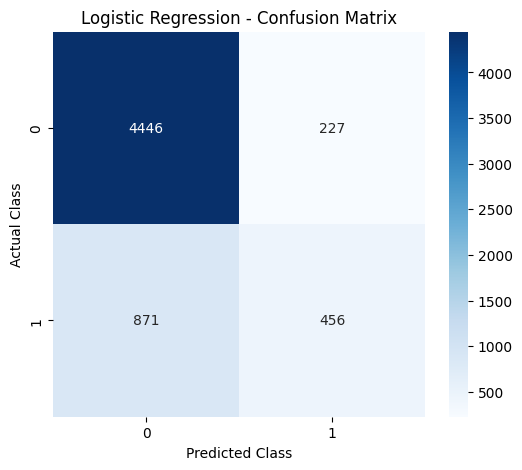

In [20]:
from sklearn.metrics import confusion_matrix

cm_lr = confusion_matrix(y_test, y_pred_lr)

print("Confusion Matrix:")
print(cm_lr)

plt.figure(figsize=(6, 5))

sns.heatmap(
    cm_lr,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.title("Logistic Regression - Confusion Matrix")
plt.xlabel("Predicted Class")
plt.ylabel("Actual Class")

plt.show()

In [21]:
from sklearn.metrics import classification_report

print(
    classification_report(
        y_test,
        y_pred_lr,
        target_names=["No Default", "Default"]
    )
)

              precision    recall  f1-score   support

  No Default       0.84      0.95      0.89      4673
     Default       0.67      0.34      0.45      1327

    accuracy                           0.82      6000
   macro avg       0.75      0.65      0.67      6000
weighted avg       0.80      0.82      0.79      6000



In [22]:
results = []

results.append({
    "ML Model": "Logistic Regression",
    "Accuracy": accuracy_lr,
    "AUC": auc_lr,
    "Precision": precision_lr,
    "Recall": recall_lr,
    "F1": f1_lr,
    "MCC": mcc_lr
})

results_df = pd.DataFrame(results)

results_df

,ML Model,Accuracy,AUC,Precision,Recall,F1,MCC
0,Logistic Regression,0.817,0.747772,0.667643,0.343632,0.453731,0.385561


In [23]:
# ============================================
# Model 2 - Decision Tree
# ============================================

from sklearn.tree import DecisionTreeClassifier

decision_tree_model = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", DecisionTreeClassifier(
        random_state=42
    ))
])

# Train
decision_tree_model.fit(X_train, y_train)

# Predictions
y_pred_dt = decision_tree_model.predict(X_test)

# Probabilities for AUC
y_prob_dt = decision_tree_model.predict_proba(X_test)[:, 1]

In [24]:
# ============================================
# Decision Tree Evaluation
# ============================================

accuracy_dt = accuracy_score(y_test, y_pred_dt)
auc_dt = roc_auc_score(y_test, y_prob_dt)
precision_dt = precision_score(y_test, y_pred_dt)
recall_dt = recall_score(y_test, y_pred_dt)
f1_dt = f1_score(y_test, y_pred_dt)
mcc_dt = matthews_corrcoef(y_test, y_pred_dt)

print("Decision Tree Results")
print("=" * 40)
print(f"Accuracy  : {accuracy_dt:.4f}")
print(f"AUC       : {auc_dt:.4f}")
print(f"Precision : {precision_dt:.4f}")
print(f"Recall    : {recall_dt:.4f}")
print(f"F1 Score  : {f1_dt:.4f}")
print(f"MCC       : {mcc_dt:.4f}")

Decision Tree Results
Accuracy  : 0.7213
AUC       : 0.6120
Precision : 0.3803
Recall    : 0.4130
F1 Score  : 0.3960
MCC       : 0.2156


In [25]:
cm_dt = confusion_matrix(y_test, y_pred_dt)

print("Confusion Matrix:")
print(cm_dt)

Confusion Matrix:
[[3780  893]
 [ 779  548]]


In [26]:
# ============================================
# K-Nearest Neighbors
# ============================================
from sklearn.neighbors import KNeighborsClassifier

knn_model = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", KNeighborsClassifier(
        n_neighbors=5
    ))
])

knn_model.fit(X_train, y_train)

print("KNN training completed.")

y_pred_knn = knn_model.predict(X_test)

y_prob_knn = knn_model.predict_proba(X_test)[:, 1]

accuracy_knn = accuracy_score(y_test, y_pred_knn)

auc_knn = roc_auc_score(y_test, y_prob_knn)

precision_knn = precision_score(y_test, y_pred_knn)

recall_knn = recall_score(y_test, y_pred_knn)

f1_knn = f1_score(y_test, y_pred_knn)

mcc_knn = matthews_corrcoef(y_test, y_pred_knn)


print("KNN Results")
print("=" * 40)
print(f"Accuracy  : {accuracy_knn:.4f}")
print(f"AUC       : {auc_knn:.4f}")
print(f"Precision : {precision_knn:.4f}")
print(f"Recall    : {recall_knn:.4f}")
print(f"F1 Score  : {f1_knn:.4f}")
print(f"MCC       : {mcc_knn:.4f}")

KNN training completed.
KNN Results
Accuracy  : 0.7935
AUC       : 0.7040
Precision : 0.5485
Recall    : 0.3753
F1 Score  : 0.4456
MCC       : 0.3330


In [27]:
# ============================================
# Naive Bayes
# ============================================

from sklearn.naive_bayes import GaussianNB

nb_categorical_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(
        handle_unknown="ignore",
        sparse_output=False
    ))
])

nb_preprocessor = ColumnTransformer(
    transformers=[
        ("num", numerical_pipeline, numerical_features),
        ("cat", nb_categorical_pipeline, categorical_features),
        ("payment", payment_pipeline, payment_features)
    ]
)

naive_bayes_model = Pipeline([
    ("preprocessor", nb_preprocessor),
    ("classifier", GaussianNB())
])

naive_bayes_model.fit(X_train, y_train)

print("Naive Bayes training completed.")

y_pred_nb = naive_bayes_model.predict(X_test)

y_prob_nb = naive_bayes_model.predict_proba(X_test)[:, 1]

accuracy_nb = accuracy_score(y_test, y_pred_nb)

auc_nb = roc_auc_score(y_test, y_prob_nb)

precision_nb = precision_score(y_test, y_pred_nb)

recall_nb = recall_score(y_test, y_pred_nb)

f1_nb = f1_score(y_test, y_pred_nb)

mcc_nb = matthews_corrcoef(y_test, y_pred_nb)


print("Naive Bayes Results")
print("=" * 40)
print(f"Accuracy  : {accuracy_nb:.4f}")
print(f"AUC       : {auc_nb:.4f}")
print(f"Precision : {precision_nb:.4f}")
print(f"Recall    : {recall_nb:.4f}")
print(f"F1 Score  : {f1_nb:.4f}")
print(f"MCC       : {mcc_nb:.4f}")

Naive Bayes training completed.
Naive Bayes Results
Accuracy  : 0.7408
AUC       : 0.7314
Precision : 0.4353
Recall    : 0.5780
F1 Score  : 0.4966
MCC       : 0.3327


In [28]:
# ============================================
# Random Forest
# ============================================

from sklearn.ensemble import RandomForestClassifier

random_forest_model = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", RandomForestClassifier(
        n_estimators=200,
        random_state=42,
        n_jobs=-1
    ))
])

random_forest_model.fit(X_train, y_train)

print("Random Forest training completed.")

y_pred_rf = random_forest_model.predict(X_test)

y_prob_rf = random_forest_model.predict_proba(X_test)[:, 1]

accuracy_rf = accuracy_score(y_test, y_pred_rf)

auc_rf = roc_auc_score(y_test, y_prob_rf)

precision_rf = precision_score(y_test, y_pred_rf)

recall_rf = recall_score(y_test, y_pred_rf)

f1_rf = f1_score(y_test, y_pred_rf)

mcc_rf = matthews_corrcoef(y_test, y_pred_rf)


print("Random Forest Results")
print("=" * 40)
print(f"Accuracy  : {accuracy_rf:.4f}")
print(f"AUC       : {auc_rf:.4f}")
print(f"Precision : {precision_rf:.4f}")
print(f"Recall    : {recall_rf:.4f}")
print(f"F1 Score  : {f1_rf:.4f}")
print(f"MCC       : {mcc_rf:.4f}")

cm_rf = confusion_matrix(y_test, y_pred_rf)

print("Confusion Matrix:")
print(cm_rf)

Random Forest training completed.
Random Forest Results
Accuracy  : 0.8142
AUC       : 0.7574
Precision : 0.6380
Recall    : 0.3693
F1 Score  : 0.4678
MCC       : 0.3848
Confusion Matrix:
[[4395  278]
 [ 837  490]]


In [29]:
# ============================================
# Final Model Comparison
# ============================================

results_df = pd.DataFrame([
    {
        "ML Model": "Logistic Regression",
        "Accuracy": accuracy_lr,
        "AUC": auc_lr,
        "Precision": precision_lr,
        "Recall": recall_lr,
        "F1 Score": f1_lr,
        "MCC": mcc_lr
    },
    {
        "ML Model": "Decision Tree",
        "Accuracy": accuracy_dt,
        "AUC": auc_dt,
        "Precision": precision_dt,
        "Recall": recall_dt,
        "F1 Score": f1_dt,
        "MCC": mcc_dt
    },
    {
        "ML Model": "KNN",
        "Accuracy": accuracy_knn,
        "AUC": auc_knn,
        "Precision": precision_knn,
        "Recall": recall_knn,
        "F1 Score": f1_knn,
        "MCC": mcc_knn
    },
    {
        "ML Model": "Naive Bayes",
        "Accuracy": accuracy_nb,
        "AUC": auc_nb,
        "Precision": precision_nb,
        "Recall": recall_nb,
        "F1 Score": f1_nb,
        "MCC": mcc_nb
    },
    {
        "ML Model": "Random Forest",
        "Accuracy": accuracy_rf,
        "AUC": auc_rf,
        "Precision": precision_rf,
        "Recall": recall_rf,
        "F1 Score": f1_rf,
        "MCC": mcc_rf
    }
])

results_df.round(4)

,ML Model,Accuracy,AUC,Precision,Recall,F1 Score,MCC
0,Logistic Regression,0.8170,0.7478,0.6676,0.3436,0.4537,0.3856
1,Decision Tree,0.7213,0.6120,0.3803,0.4130,0.3960,0.2156
2,KNN,0.7935,0.7040,0.5485,0.3753,0.4456,0.3330
3,Naive Bayes,0.7408,0.7314,0.4353,0.5780,0.4966,0.3327
4,Random Forest,0.8142,0.7574,0.6380,0.3693,0.4678,0.3848


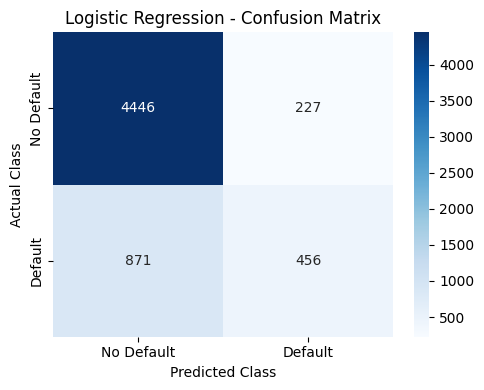

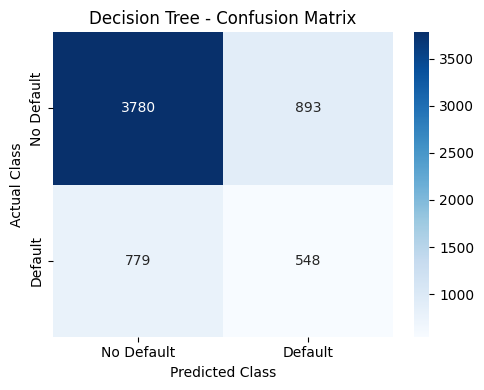

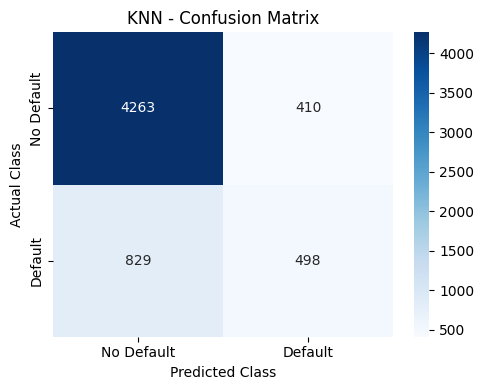

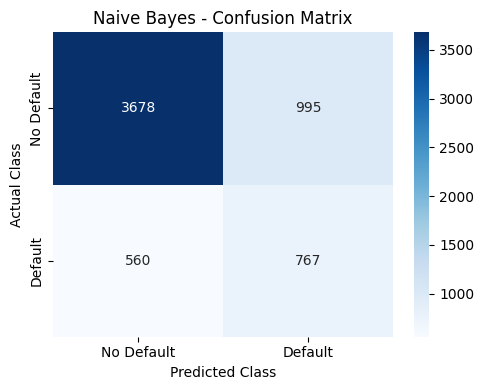

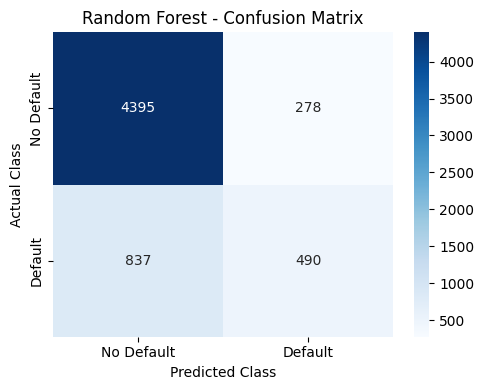

In [30]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

# Store predictions
predictions = {
    "Logistic Regression": y_pred_lr,
    "Decision Tree": y_pred_dt,
    "KNN": y_pred_knn,
    "Naive Bayes": y_pred_nb,
    "Random Forest": y_pred_rf
}

# Plot confusion matrices
for model_name, predictions_model in predictions.items():

    cm = confusion_matrix(y_test, predictions_model)

    plt.figure(figsize=(5, 4))

    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        xticklabels=["No Default", "Default"],
        yticklabels=["No Default", "Default"]
    )

    plt.title(f"{model_name} - Confusion Matrix")
    plt.xlabel("Predicted Class")
    plt.ylabel("Actual Class")
    plt.tight_layout()
    plt.show()

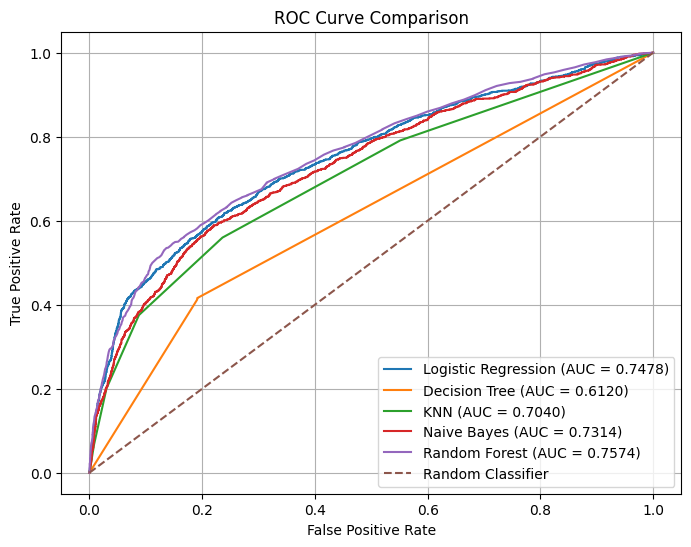

In [31]:
from sklearn.metrics import roc_curve, auc

# Store probability predictions
probabilities = {
    "Logistic Regression": y_prob_lr,
    "Decision Tree": y_prob_dt,
    "KNN": y_prob_knn,
    "Naive Bayes": y_prob_nb,
    "Random Forest": y_prob_rf
}

plt.figure(figsize=(8, 6))

for model_name, probabilities_model in probabilities.items():

    fpr, tpr, _ = roc_curve(
        y_test,
        probabilities_model
    )

    roc_auc = auc(fpr, tpr)

    plt.plot(
        fpr,
        tpr,
        label=f"{model_name} (AUC = {roc_auc:.4f})"
    )

# Random classifier reference line
plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Random Classifier"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")

plt.title("ROC Curve Comparison")

plt.legend()
plt.grid(True)
plt.show()

In [32]:
results_display = results_df.copy()

metric_columns = [
    "Accuracy",
    "AUC",
    "Precision",
    "Recall",
    "F1 Score",
    "MCC"
]

results_display[metric_columns] = (
    results_display[metric_columns]
    .round(4)
)

results_display

,ML Model,Accuracy,AUC,Precision,Recall,F1 Score,MCC
0,Logistic Regression,0.8170,0.7478,0.6676,0.3436,0.4537,0.3856
1,Decision Tree,0.7213,0.6120,0.3803,0.4130,0.3960,0.2156
2,KNN,0.7935,0.7040,0.5485,0.3753,0.4456,0.3330
3,Naive Bayes,0.7408,0.7314,0.4353,0.5780,0.4966,0.3327
4,Random Forest,0.8142,0.7574,0.6380,0.3693,0.4678,0.3848


In [33]:
logistic_model
decision_tree_model
knn_model
naive_bayes_model
random_forest_model

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['limit_bal', 'age',
                                                   'bill_statement_sep',
                                                   'bill_statement_aug',
                                                   'bill_statement_jul',
                                                   'bill_statement_jun',
                                                   'bill_statement_may',
                                                   'bill_statement_apr',
                                                   'previous_payment_sep',
                                                   'previous_payment_au...
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['sex', 'education',
                                                   'marriage']),
                                                 ('payment',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['payment_status_sep',
                                                   'payment_status_aug',
                                                   'payment_status_jul',
                                                   'payment_status_jun',
                                                   'payment_status_may',
                                                   'payment_status_apr'])])),
                ('classifier',
                 RandomForestClassifier(n_estimators=200, n_jobs=-1,
                                        random_state=42))])

In [34]:
import joblib
import os

# Create model directory
os.makedirs("model", exist_ok=True)

# Save all five trained models
joblib.dump(
    logistic_model,
    "model/logistic_regression.pkl"
)

joblib.dump(
    decision_tree_model,
    "model/decision_tree.pkl"
)

joblib.dump(
    knn_model,
    "model/knn.pkl"
)

joblib.dump(
    naive_bayes_model,
    "model/naive_bayes.pkl"
)

joblib.dump(
    random_forest_model,
    "model/random_forest.pkl"
)

print("All models saved successfully!")

All models saved successfully!


In [35]:
from google.colab import files

files.download("model/logistic_regression.pkl")
files.download("model/logistic_regression.pkl")
files.download("model/decision_tree.pkl")
files.download("model/knn.pkl")
files.download("model/naive_bayes.pkl")
files.download("model/random_forest.pkl")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

...

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [36]:
X_test
y_test

,default_payment_next_month
6907,0
24575,0
26766,0
2156,1
3179,0
...,...
8836,0
1259,0
27309,0
29583,0


In [37]:
test_data = X_test.copy()

test_data["default_payment_next_month"] = y_test.values

test_data.to_csv(
    "test_data.csv",
    index=False
)

print("Test data saved successfully.")
print(test_data.shape)

Test data saved successfully.
(6000, 24)


In [38]:
import joblib
from google.colab import drive
drive.mount('/content/drive/')

loaded_model = joblib.load(
    "/content/drive/MyDrive/credit-card-default-project/model/logistic_regression.pkl"
)

test_prediction = loaded_model.predict(X_test)

print("Predictions generated:", len(test_prediction))

Drive already mounted at /content/drive/; to attempt to forcibly remount, call drive.mount("/content/drive/", force_remount=True).
Predictions generated: 6000


In [39]:
!ls -l /content/drive/MyDrive/credit-card-default-project

total 4
drwx------ 2 root root 4096 Aug 16 07:04 model


In [40]:
test_data = X_test.copy()

test_data["default_payment_next_month"] = y_test.values

test_data.to_csv(
    "/content/drive/MyDrive/credit-card-default-project/test_data.csv",
    index=False
)

print("Test data created.")
print("Shape:", test_data.shape)

Test data created.
Shape: (6000, 24)


In [42]:
import shutil

shutil.make_archive(
    "credit_card_models",
    "zip",
    "model"
)

print("Model ZIP created.")

Model ZIP created.


In [44]:
from google.colab import files

files.download("credit_card_models.zip")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [45]:
files.download("test_data.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>